# Visualization Examples with Python

This notebook will provide an overview of popular visualization packages in Python including matplotlib, Seaborn, and Plotly. The examples below will help you:
- Develop the ability to create powerful visualizations using the matplotlib and seaborn packages
- Plot and interpret scatterplots and time series plots
- Format settings of graphs
- Learn to create and interpret more advanced graphs such as histograms, box plots and volatility surface charts
- Create interactive charts with Plotly Express that can be exported as shareable web html files or hosted online

### <font color = 'blue'> **Section 1 - Importing Packages and Data** </font>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import plotly.express as px #This package first needs to be installed with Anaconda

In [3]:
# added  date_format='ISO8601' see https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html
sp500 = pd.read_csv("StockData/SP500.csv", index_col=['Date'], parse_dates=['Date'], date_format='ISO8601')
aapl = pd.read_csv("StockData/aapl.csv", parse_dates=['Date'], index_col=['Date'], date_format={"Date": "%d/%m/%Y"})

In [4]:
#%% Calculating Returns
sp500['Returns'] = sp500['Close'] / sp500['Close'].shift(1) - 1
    #daily return (Close/Prev Close) - 1

aapl['Returns'] = aapl['Close'].pct_change()

aapl

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.410525,117258400.0,NaN
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.389106,43971200.0,-0.052174
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.360548,26432000.0,-0.073394
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.369472,21610400.0,0.024753
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.380182,18362400.0,0.028984
...,...,...,...,...,...,...,...
2019-07-30,208.759995,210.160004,207.309998,208.779999,208.779999,33935700.0,-0.004292
2019-07-31,216.419998,221.369995,211.300003,213.039993,213.039993,69281400.0,0.020404
2019-08-01,213.899994,218.029999,206.740005,208.429993,208.429993,54017900.0,-0.021639


### <font color = 'blue'> **Section 2 - Simple Visualizations with Pandas** </font>

#### Line Graph from Pandas Column

<Axes: xlabel='Date'>

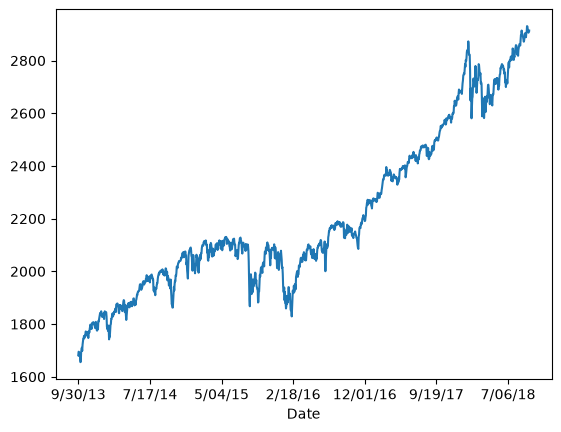

In [5]:
#%% Visualizations
#pandas has a built-in formula
sp500['Close'].plot()

#### Multiple Line Graphs on same Plot
- You can keep adding .plot formulas to plot on the same graph

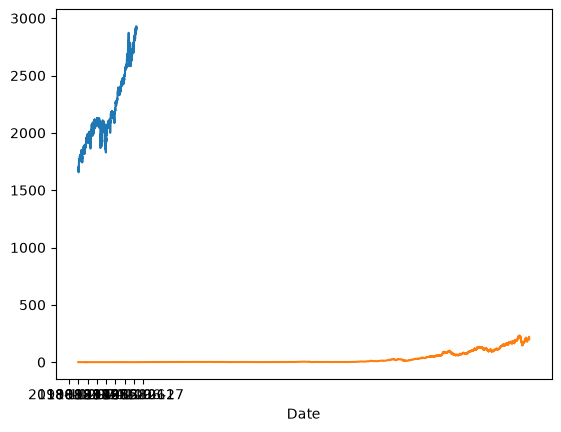

In [6]:
sp500['Close'].plot()
aapl['High'].plot()
plt.show()

### <font color = 'blue'> **Section 3 - Simple Visualizations with MatplotLib** </font>

- Using Matplotlib, you can customize the title, legend, axis labels, etc.
- plt.title(), plt.xlabel(), plt.ylabel(), plt.legend()
- https://matplotlib.org/stable/gallery/showcase/anatomy.html

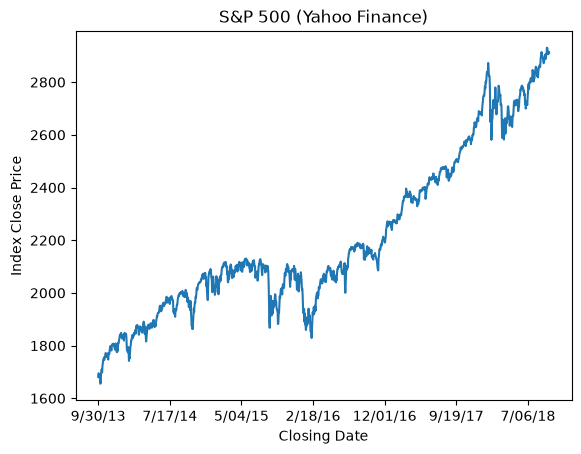

In [7]:
#%% Simple Visualization
# dataframe[column].plot()
# changes to the graph settings
# plt.show()
sp500['Close'].plot()
plt.ylabel("Index Close Price")
plt.title("S&P 500 (Yahoo Finance)")
plt.xlabel("Closing Date")
plt.show()

### <font color = 'blue'> **Section 4 - Annotated Line Chart with MatplotLib** </font>

In [8]:
#With Annotations
#max share price
maxPrice = sp500['Close'].max()
minPrice = sp500['Close'].min()
#dates when the max and min happened ---> use .idxmax() and .idxmin()
maxDate = sp500['Close'].idxmax()
minDate = sp500['Close'].idxmin()

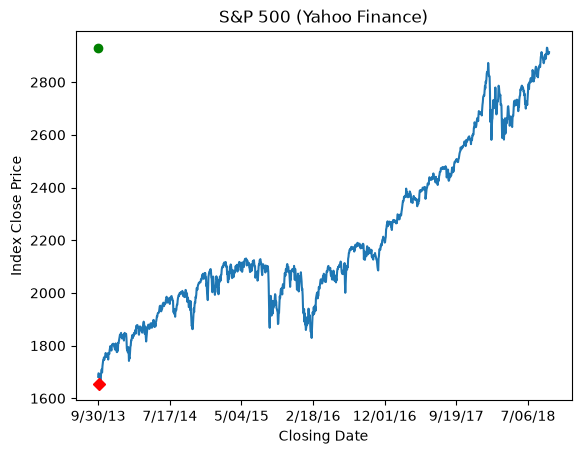

In [9]:
sp500['Close'].plot()
# aapl['Close'].plot()
plt.ylabel("Index Close Price")
plt.title("S&P 500 (Yahoo Finance)")
plt.xlabel("Closing Date")

#Add some annotations
#Plot the max and min share price in this time period
    #need the x,y coordinates of the annotations
plt.plot(maxDate, maxPrice, color='green', marker='o')
plt.plot(minDate, minPrice, color='red', marker='D')   
    #matplotlib marker
    #https://matplotlib.org/api/markers_api.html
    
#plot the labels using .annotate(xy=(location of the marker), xytext=(location of the label))
        #DateOFfset adds #of days to a DateTime variable
# plt.annotate("High",xy=(maxDate,maxPrice),xytext=(pd.to_datetime("2015-05-01"), 2800),
#             arrowprops=dict(facecolor='black',shrink=0.05))


# plt.annotate("Low",xy=(minDate,minPrice),
#             xytext=(f'{minDate}' )) # {pd.DateOffset(50)} {minPrice + 10}') )

plt.show()

### <font color = 'blue'> **Section 5 - Multiple Line Charts** </font>

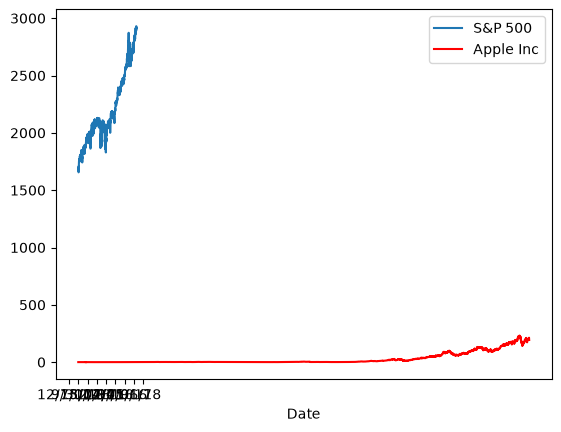

In [10]:
#%% Multiple line charts
sp500['Close'].plot()
# aapl['Close'].plot()
plt.plot(aapl.index, aapl['Close'], color='red')
plt.legend(['S&P 500','Apple Inc'])
plt.show()

In [11]:
#%% Multiple line charts seperate graphs
#create each individual graph and then plot them together
# plt.subplot(a, b, c); a = num of rows, b= num of cols, c = graph #

jnj = pd.read_csv("StockData/JNJ.csv", parse_dates=['Date'], index_col=['Date'])
jpm = pd.read_csv("StockData/JPM.csv", parse_dates=['Date'], index_col=['Date'])

numChartRows = 2
numChartCols = 2

plt.figure(figsize=(10, 6))

plt.subplot(numChartRows,numChartCols,1)
plt.plot(sp500.index,sp500['Close'])
plt.title("S&P Close")

plt.subplot(numChartRows,numChartCols,2)
plt.plot(aapl.index,aapl['Close'])
plt.title("AAPL")

plt.subplot(numChartRows,numChartCols,3)
plt.plot(jnj.index,jnj['Close'])
plt.title("JNJ")

plt.subplot(numChartRows,numChartCols,4)
plt.plot(jpm.index,jpm['Close'])
plt.title("JPM")

# plt.ylim(bottom=0,top=aapl['Close'].max())

plt.tight_layout() #tries to fit in the charts when resizing
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'StockData/JNJ.csv'

In [ ]:
#%% Multiple line charts diff Y-Axis

# x, y = 10, 20
# def fnCubeSquare(x):
#     return x**3, x**2

fig, ax1 = plt.subplots()
    #fig is the container, ax1 is the chart inside
# cube, square = fnCubeSquare(5)
ax1.plot(sp500.index, sp500['Close'],'blue')
ax1.set_ylabel("S&P 500",color='blue')

ax2 = ax1.twinx() #twinx copies the x-axis
    #makes sure the 2nd chart has the same ranges of dates
ax2.plot(aapl.index, aapl['Close'],'black', alpha=0.6)
ax2.set_ylabel("AAPL",color='black')
# fig.show()

Text(0, 0.5, 'AAPL')

In [ ]:
#%% Multiple line charts diff - Yaxis using Pandas
aapl['Close'].plot()
sp500['Close'].plot(secondary_y=True)
plt.show()

### <font color = 'blue'> **Section 6 - Histograms** </font>

In [ ]:
sp500['Returns'].hist(figsize=(7,7))
plt.show()

In [ ]:
#Providing the # of bins
aapl['Returns'].hist(bins=100)
plt.show()

#### Histogram with Density Line

In [ ]:
#Histogram with density line
from scipy.stats import norm
import numpy as np
returns = aapl['Returns'].dropna().values
rtn500 = sorted(returns) #good practice to sort when going to use as a distribution

#Find the mean() and std() of the sp500 returns and plot a normal distribution overlay
avgReturn = np.mean(returns)
stdReturn = np.std(returns)

normReturns = np.linspace(avgReturn - 3*stdReturn, avgReturn + 3*stdReturn, 100)
plt.hist(returns, bins=100)
plt.plot(normReturns, norm.pdf(normReturns, avgReturn, 0.005))
#plt.text(-0.03,60, r'$\mu$ = %.3f $\sigma$ = %.3f' % (mu500, std500))
plt.annotate(r'$\mu$ = %.3f $\sigma$ = %.3f' % (avgReturn, stdReturn), xy=(.02,60))
plt.title('Apple Returns')
plt.show()

### <font color = 'blue'> **Section 7 - Seaborn Package** </font>
- http://seaborn.pydata.org/

#### Box & Whiskers Plot (Boxplot)

In [ ]:
#Seaborn box whiskers
import seaborn as sns
sp500['Month'] = sp500.index.month
sns.boxplot(x="Month",y="Returns",data=sp500)
plt.show()

In [ ]:
sns.lineplot(x=sp500.index, y="Close", data=sp500)
plt.show()

### <font color = 'blue'> **Section 8 - Styles** </font>

In [ ]:
import matplotlib.style as style
style.available

In [ ]:
#Code to test out different styles
for x in style.available:
    style.use(x)
    print(x)
    plt.plot(aapl.index, aapl['Close'])
    plt.show()

### <font color = 'blue'> **Section 9 - Plotly Package** </font>
- allows for interactive charts
- https://plotly.com/python/plotly-express/

In [ ]:
fig = px.line(sp500, y="Close", title='S&P 500')
fig.show()

In [ ]:
sp500['Ticker'] = 'SP500'
aapl['Ticker'] = 'AAPL'

intc = pd.read_csv("StockData/INTC.csv", parse_dates=['Date'], index_col=['Date'])
intc['Returns'] = intc['Close'].pct_change()
intc['Ticker'] = 'INTC'

ibm = pd.read_csv("StockData/IBM.csv", parse_dates=['Date'], index_col=['Date'])
ibm['Returns'] = ibm['Close'].pct_change()
ibm['Ticker'] = 'IBM'

stockData = pd.concat([intc,aapl,ibm])
stockData

In [ ]:
px.line(stockData, x=stockData.index, y="Close", color="Ticker")

In [ ]:
px.line(stockData, x=stockData.index, y="Returns", color="Ticker")

#### Example of Stacked Bar Chart

In [ ]:
finDeals = pd.read_excel("ExData/Data Manipulation Worksheet.xlsx",sheet_name='Financing Table Clean')
figBar = px.bar(finDeals,
             x='INDUSTRY',
             y='SIZE',
             color='INDUSTRY', hover_name="ISSUER",
            title="Total Deal Value by Industry")
figBar.show()

#code to save the graph as an html file:
#figBar.write_html(file="ADAPT2021/Output/plotlyExample.html",auto_open=True)

### <font color = 'blue'> **Section 10 - Surface Volatility Plot** </font>

In [ ]:
#%% SPY
df = pd.read_csv("ExData/spx.csv")
df.set_index(['Strike'],inplace=True)
#df.info()
df.head(20)

In [ ]:
Z=df.values * 100 #all the implied vol's in %
Y=df.index.values #all the strike prices
X=df.columns.astype(str).values
    #could calculate time to expiry, can take today's date - maturity date

#df.index.values

In [ ]:
import plotly.graph_objs as go

fig = go.Figure(
    data=[ go.Surface(z=Z,y=Y,x=X)],
    
    layout=dict(
        title = 'Vol Surface',
        autosize = True,
        width = 900,
        height = 700,
        margin = dict(l = 65, r = 50, b = 65, t = 90),
        scene = dict(
            aspectratio = dict(x = 1, y = 1, z = .6),
            xaxis = dict(title='Maturity'),
            yaxis = dict(title='Strike'),
            zaxis = dict(title='Volatility')
            )
        )
    )

fig.show()